In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import dask.dataframe as dd
import dask.array as da
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp

sys.path.insert(0, "/data/user/akatil/electron_neutrino/for_real/analysis_chain/")

from analysis_helpers import get_mean_upgrade_positions

In [2]:
#getting the geometry frame. We want this to calculate the mean of upgrade om x and y positions
gcd_infile = dataio.I3File('/home/akatil/GeoCalibDetectorStatus_ICUpgrade.v58.mixed.V1.i3.bz2')

f_geo = gcd_infile
geo_frame = f_geo.pop_frame(icetray.I3Frame.Geometry)
geo = geo_frame['I3Geometry']

ux, uy, uz = get_mean_upgrade_positions(geo)

fCC = h5py.File('../../../dataset_complete/merger/merged_CC.h5')#delete_merger_CC.h5', 'r')
fNC = h5py.File('../../../dataset_complete/merger/merged_NC.h5')#delete_merger.h5', 'r')

In [3]:
x = da.from_array(fCC['EventCounter'][:], chunks=(1000,))

In [4]:
fCC['OMMapTrue']

<HDF5 dataset "OMMapTrue": shape (104154351,), type "|V128">

In [5]:
def get_dict(f):
    data_dict = {}
    
    for key in f.keys():
        #data = f[key][:]
        print(key)
        if key == 'filename':
            continue
        elif key == 'OMMapReco' or key == 'OMMapTrue':
            data = da.from_array(f[key], chunks=(1000,))
        else:
            data = da.from_array(f[key]['value'], chunks=(1000,))
        
        data_dict[key] = data

    return data_dict

In [ ]:
data_dictCC = get_dict(fCC)
data_dictNC = get_dict(fNC)

Azimuth
Beta1
Beta1Reco
Beta2
Beta2Reco
Beta3
Beta3Reco
Beta4
Beta4Reco
Beta5
Beta5Reco
CogX
CogY
CogZ
EventCounter
Inelasticity
OMMapReco
OMMapTrue
PrimaryEnergy
RecoDirX
RecoDirY
RecoDirZ
RecoEnergy
RecoVertexTime
RecoX
RecoY
RecoZ
SecondaryEnergy
TotalCharge
TotalmDOMCharge
TrueTime
TrueX
TrueY
TrueZ
Zenith
filename
Azimuth


In [ ]:
data_dictNC['OMMapTrue']

In [8]:
data_dictCC['EventCounter']

dask.array<array, shape=(2548558,), dtype=float64, chunksize=(1000,), chunktype=numpy.ndarray>

In [10]:
emin, emax = 50, 60

imin, imax = 0, 0.1

interaction_type = 1

f = data_dictNC

event_counter = f['EventCounter']
print(event_counter)
print('started counter')

om_counter = f['OMMapTrue']['om_counter']
print('got om counter')

energy = f['PrimaryEnergy']
inelasticity = f['Inelasticity']

trueX = f['TrueX']
trueY = f['TrueY']
trueZ = f['TrueZ']

energy_boolean = (energy >= emin) & (energy <= emax)
inelasticity_boolean = (inelasticity >= imin) & (inelasticity <= imax)
vertex_boolean = (trueZ <= uz+150)&(trueZ >= uz-150)&(trueX <= ux+50)&(trueX >= ux-50)&(trueY <= uy+40)&(trueY >= uy-40)
print('defined booleans')

if interaction_type == 0:
    event_boolean = energy_boolean & inelasticity_boolean & vertex_boolean
if interaction_type == 1:
    event_boolean = energy_boolean & vertex_boolean

select_event_counter = event_counter[event_boolean]
print(select_event_counter.compute())


dask.array<array, shape=(2193648,), dtype=float64, chunksize=(1000,), chunktype=numpy.ndarray>
started counter
got om counter
defined booleans
[2.00000000e+10 2.00000000e+10 2.00000012e+10 ... 2.00022402e+10
 2.00022403e+10 2.00022403e+10]


In [26]:
om_event_condition = da.where(da.isin(om_counter, set(select_event_counter.compute())))[0]

In [ ]:
data_dictNC['OMMapTrue']['time_residual'][om_event_condition].compute()

/cvmfs/icecube.opensciencegrid.org/py3-v4.3.0/Ubuntu_22.04_x86_64/lib/python3.11/site-packages/dask/array/slicing.py:1084: PerformanceWarning: Increasing number of chunks by factor of 61556
  p = blockwise(


In [40]:
om_event_condition.compute()

KeyboardInterrupt: 

In [37]:
data_dictNC['OMMapTrue']['time_residual'][om_event_condition]

/cvmfs/icecube.opensciencegrid.org/py3-v4.3.0/Ubuntu_22.04_x86_64/lib/python3.11/site-packages/dask/array/slicing.py:1084: PerformanceWarning: Increasing number of chunks by factor of 61556
  p = blockwise(


dask.array<slice_with_int_dask_array_aggregate, shape=(nan,), dtype=float64, chunksize=(nan,), chunktype=numpy.ndarray>

In [9]:
emin, emax = 50, 60

imin, imax = 0, 0.1

def get_filtered_data(f, interaction_type):
    #### First make event level cuts ######
    # cuts on energy
    # cuts on inelasticity, only for CC
    # cuts on vertex

    total_events = f['PrimaryEnergy'].shape[0]
    print(f'total events is {total_events}')
    num_samples = 10000
    random_indices = np.random.randint(0, total_events, size=num_samples)
    
    event_counter = f['EventCounter']
    print(event_counter)
    print('started counter')
    
    om_counter = f['OMMapTrue']['om_counter']
    print('got om counter')
    
    energy = f['PrimaryEnergy']
    inelasticity = f['Inelasticity']
    
    trueX = f['TrueX']
    trueY = f['TrueY']
    trueZ = f['TrueZ']
    
    energy_boolean = (energy >= emin) & (energy <= emax)
    inelasticity_boolean = (inelasticity >= imin) & (inelasticity <= imax)
    vertex_boolean = (trueZ <= uz+150)&(trueZ >= uz-150)&(trueX <= ux+50)&(trueX >= ux-50)&(trueY <= uy+40)&(trueY >= uy-40)
    print('defined booleans')

    if interaction_type == 0:
        event_boolean = energy_boolean & inelasticity_boolean & vertex_boolean
    if interaction_type == 1:
        event_boolean = energy_boolean & vertex_boolean
    
    select_event_counter = event_counter[event_boolean]
    print(select_event_counter.compute())
    
    # Apply the cuts
    filtered_data = {}
    
    # Loop through all keys (datasets) and apply the cut
    print('starting_loop')
    for key in f.keys():
        print(key)
        if key == 'OMMapReco' or key == 'OMMapTrue':
            data = f[key]
            om_event_condition = da.where(da.isin(om_counter, set(select_event_counter))[0]
            filtered_data[key] = data[om_event_condition]
        else:
            data = f[key]
            filtered_data[key] = data[event_boolean]  # This applies the condition to each dataset

    return filtered_data

In [ ]:
filtered_dataCC = get_filtered_data(data_dictCC, 0)

total events is 2548558
dask.array<array, shape=(2548558,), dtype=float64, chunksize=(1000,), chunktype=numpy.ndarray>
started counter
got om counter
defined booleans
[1.00000739e+10 1.00000008e+10 1.00000009e+10 ... 1.00025611e+10
 1.00025617e+10 1.00025616e+10]
starting_loop
Azimuth
Beta1
Beta1Reco
Beta2
Beta2Reco
Beta3
Beta3Reco
Beta4
Beta4Reco
Beta5
Beta5Reco
CogX
CogY
CogZ
EventCounter
Inelasticity
OMMapReco


/cvmfs/icecube.opensciencegrid.org/py3-v4.3.0/Ubuntu_22.04_x86_64/lib/python3.11/site-packages/dask/array/routines.py:1824: PerformanceWarning: Increasing number of chunks by factor of 2549
  mapped = blockwise(


In [1]:
emin, emax = 50, 60

imin, imax = 0, 0.1

def get_filtered_data(f, interaction_type):
    #### First make event level cuts ######
    # cuts on energy
    # cuts on inelasticity, only for CC
    # cuts on vertex

    total_events = f['PrimaryEnergy'].shape[0]
    print(f'total events is {total_events}')
    num_samples = 10000
    random_indices = np.random.randint(0, total_events, size=num_samples)
    
    event_counter = f['EventCounter']['value']#[random_indices]#[0:200099]
    print(event_counter)
    print('started counter')
    
    om_counter = f['OMMapTrue']['om_counter']
    #om_counter_condition = np.where(np.isin(om_counter, event_counter))[0]
    #om_counter = om_counter[om_counter_condition]#[random_indices]#[0:200099]
    print('got om counter')
    
    energy = f['PrimaryEnergy']['value']#[random_indices]#[0:200099]
    inelasticity = f['Inelasticity']['value']#[random_indices]#[0:200099]
    
    trueX = f['TrueX']['value']#[random_indices]#[0:200099]
    trueY = f['TrueY']['value']#[random_indices]#[0:200099]
    trueZ = f['TrueZ']['value']#[random_indices]#[0:200099]
    
    energy_boolean = (energy >= emin) & (energy <= emax)
    inelasticity_boolean = (inelasticity >= imin) & (inelasticity <= imax)
    vertex_boolean = (trueZ <= uz+150)&(trueZ >= uz-150)&(trueX <= ux+50)&(trueX >= ux-50)&(trueY <= uy+40)&(trueY >= uy-40)
    print('defined booleans')

    if interaction_type == 0:
        event_boolean = energy_boolean & inelasticity_boolean & vertex_boolean
    if interaction_type == 1:
        event_boolean = energy_boolean & vertex_boolean
    
    select_event_counter = event_counter[event_boolean]
    print(select_event_counter)
    
    # Apply the cuts
    filtered_data = {}
    
    # Loop through all keys (datasets) and apply the cut
    print('starting_loop')
    for key in f.keys():
        #data = f[key]#[random_indices]#[0:200099]
        if key == 'OMMapReco' or key == 'OMMapTrue':
            data = f[key]#[om_counter_condition]
            om_event_condition = np.where(np.isin(om_counter, select_event_counter))[0]
            filtered_data[key] = data[om_event_condition]
        else:
            data = f[key]#[random_indices]
            filtered_data[key] = data[event_boolean]  # This applies the condition to each dataset

    return filtered_data

In [2]:
filtered_dataCC = get_filtered_data(data_dictCC, 0)

NameError: name 'data_dictCC' is not defined

In [6]:
filtered_dataNC = get_filtered_data(fNC, 1)

In [7]:
def make1D_histograms(trueCC, trueNC, recoCC, recoNC, label, mask):

    if mask:
        tRes_min = -10
        tRes_max = 300

        true_maskCC = (trueCC >= tRes_min)&(trueCC <= tRes_max)
        true_maskNC = (trueNC >= tRes_min)&(trueNC <= tRes_max)

        reco_maskCC = (recoCC >= tRes_min)&(recoCC <= tRes_max)
        reco_maskNC = (recoNC >= tRes_min)&(recoNC <= tRes_max)

        trueCC = trueCC[true_maskCC]
        trueNC = trueNC[true_maskNC]

        recoCC = recoCC[reco_maskCC]
        recoNC = recoNC[reco_maskNC]

    ks_statistic_true, pvalue_true = ks_2samp(trueCC, trueNC)

    ks_statistic_reco, pvalue_reco = ks_2samp(recoCC, recoNC)
        
    plt.hist(trueCC, bins = 100, histtype='step', log = True, density=True, label='CC', lw=1.5)
    plt.hist(trueNC, bins = 100, histtype='step', log = True, density=True, label='NC', lw=1.5)
    plt.legend()
    plt.text(0.7, 0.65, r'KS statistic = ' + str(np.round(ks_statistic_true, 3)), transform=plt.gca().transAxes)
    plt.text(0.7, 0.60, r'p-value = ' + str(np.round(pvalue_true, 3)), transform=plt.gca().transAxes)
    plt.xlabel(label)
    plt.title('Energy {} - {} GeV|True'.format(emin, emax))

    plt.show()

    plt.hist(recoCC, bins = 100, histtype='step', log = True, density=True, label='CC', lw=1.5)
    plt.hist(recoNC, bins = 100, histtype='step', log = True, density=True, label='NC', lw=1.5)
    plt.legend()
    plt.text(0.7, 0.65, r'KS statistic = ' + str(np.round(ks_statistic_reco, 3)), transform=plt.gca().transAxes)
    plt.text(0.7, 0.60, r'p-value = ' + str(np.round(pvalue_reco, 3)), transform=plt.gca().transAxes)
    plt.xlabel(label)
    plt.title('Energy {} - {} GeV|Reco'.format(emin, emax))

    plt.show()

In [8]:
filtered_dataCC['OMMapTrue']
filtered_dataCC['OMMapReco']

array([(121429, 9416, 0, 0, 1,   0, 1.82112378, 166.37875657, 0.63064605, 10268.17231729,  3.59888489, -62.53983325, -15.1925479 , 1.00000739e+10, 26.9048764, -31.316284 , -247.9914731,   88.45693567),
       (121429, 9416, 0, 0, 1,   1, 2.04510318, 183.27346933, 1.20473552, 10232.04140572,  3.54709429, -62.58878115,   2.890641  , 1.00000739e+10, 26.956667 , -31.2673361, -266.074662 ,   60.03282648),
       (121429, 9416, 0, 0, 1,   2, 2.14786878, 191.481906  , 1.46195948, 10208.7074744 ,  3.54709429, -62.58878115,  11.601317  , 1.00000739e+10, 26.956667 , -31.2673361, -274.785338 ,   32.18445658),
       ...,
       (121429, 4078, 0, 0, 1, 121, 1.01363618, 462.69082344, 0.89871562, 11947.91599729, 52.79109632,  27.8362089 ,  11.23704805, 1.00000051e+10, 18.164966 , -51.0019594, -481.9914731, 1619.88929499),
       (121429, 4078, 0, 0, 1, 122, 1.22363832, 398.15299024, 0.81447327, 11496.73712969, 56.66606232,  57.3219134 , -57.67976305, 1.00000051e+10, 14.29     , -80.4876639, -413.074

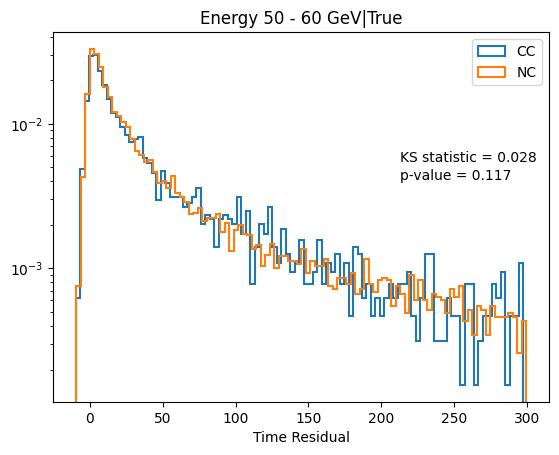

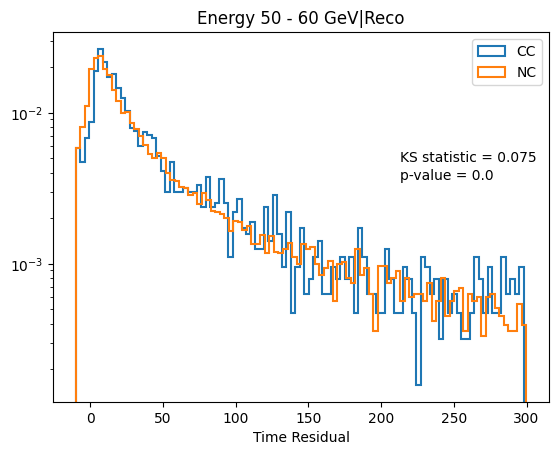

In [9]:
make1D_histograms(filtered_dataCC['OMMapTrue']['time_residual'], filtered_dataNC['OMMapTrue']['time_residual'],
                  filtered_dataCC['OMMapReco']['time_residual_reco'], filtered_dataNC['OMMapReco']['time_residual_reco'],
                  'Time Residual', mask=True)

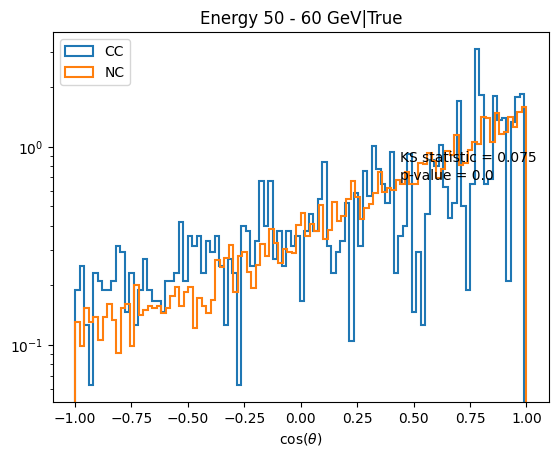

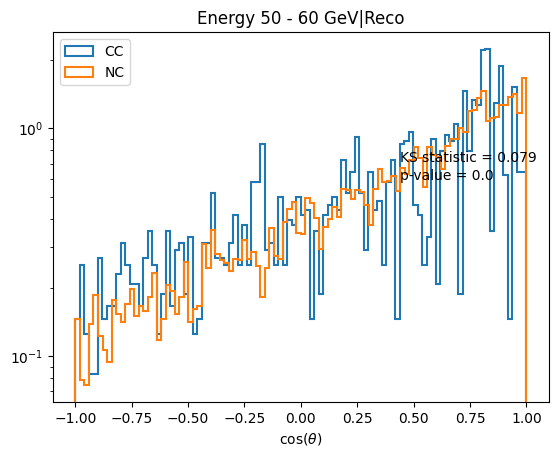

In [10]:
make1D_histograms(np.cos(filtered_dataCC['OMMapTrue']['angle']), np.cos(filtered_dataNC['OMMapTrue']['angle']),
                  -np.cos(filtered_dataCC['OMMapReco']['angle_reco']), -np.cos(filtered_dataNC['OMMapReco']['angle_reco']),
                  r'$\cos (\theta)$', mask=False)

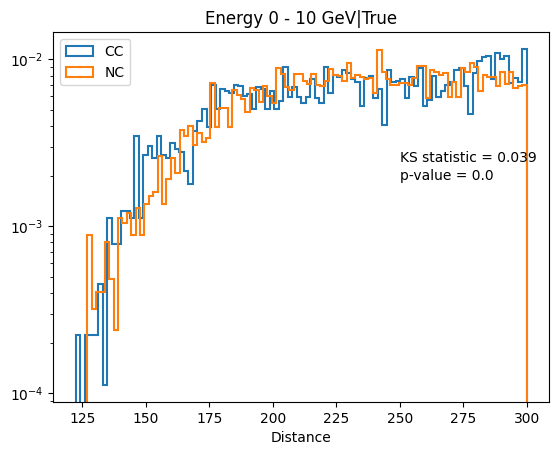

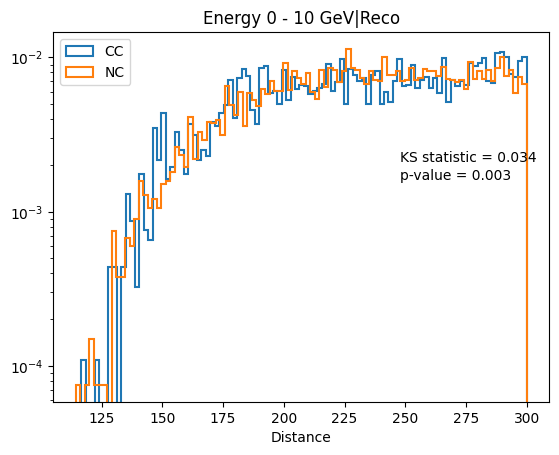

In [65]:
make1D_histograms(filtered_dataCC['OMMapTrue']['distance'], filtered_dataNC['OMMapTrue']['distance'],
                  filtered_dataCC['OMMapReco']['distance_reco'], filtered_dataNC['OMMapReco']['distance_reco'],
                  'Distance', mask=True)

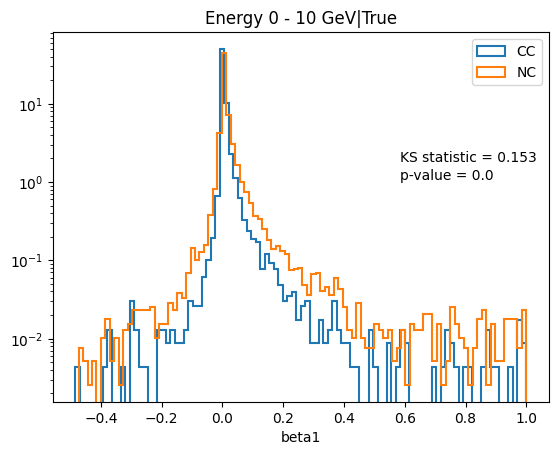

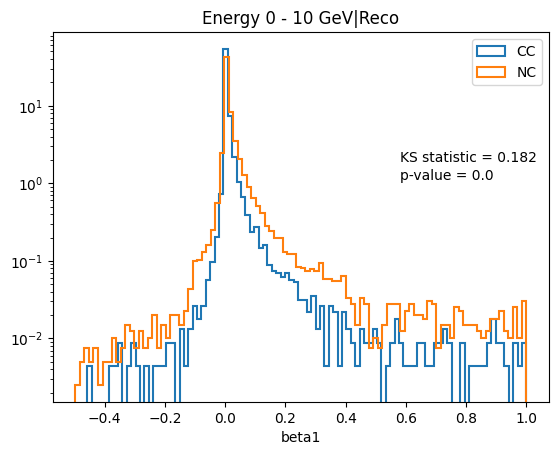

In [66]:
make1D_histograms(filtered_dataCC['Beta2']['value'], filtered_dataNC['Beta2']['value'],
                  filtered_dataCC['Beta2Reco']['value'], filtered_dataNC['Beta2Reco']['value'],
                  'beta1', mask=True)

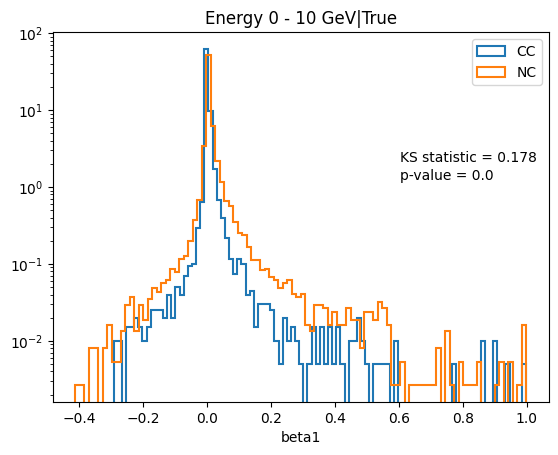

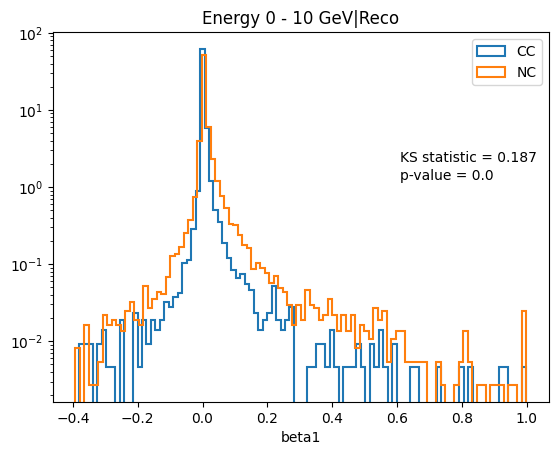

In [67]:
make1D_histograms(filtered_dataCC['Beta5']['value'], filtered_dataNC['Beta5']['value'],
                  filtered_dataCC['Beta5Reco']['value'], filtered_dataNC['Beta5Reco']['value'],
                  'beta1', mask=True)